In [1]:
#Lectura de archivos
import kagglehub
import os
import pandas as pd
import json

# Data viz
from sklearn import set_config
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns


/home/jimmii/Documentos/DiplomadoCienciaDeDatos2025-2026/RepoJime/-Titulacion-DiplomadoCienciaDeDatos/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download latest version
path = kagglehub.dataset_download("datasnaek/youtube")

print("Path to dataset files:", path)

Path to dataset files: /home/jimmii/.cache/kagglehub/datasets/datasnaek/youtube/versions/24


In [3]:
# Listar los archivos para saber el nombre exacto
archivos = os.listdir(path)
print("Archivos disponibles:", archivos)

Archivos disponibles: ['US_category_id.json', 'USvideos.csv', 'GBvideos.csv', 'GB_category_id.json', 'GBcomments.csv', 'UScomments.csv']


In [4]:
csv_path_GBvideos= os.path.join(path, 'GBvideos.csv')
df_GBvideos = pd.read_csv(csv_path_GBvideos, on_bad_lines='skip')
csv_path_GBcomments= os.path.join(path, 'GBcomments.csv')
df_GBcomments = pd.read_csv(csv_path_GBcomments, on_bad_lines='skip')

In [5]:
df_GBvideos.head(5)

,video_id,title,channel_title,category_id,tags,views,likes,dislikes,comment_total,thumbnail_link,date
0,jt2OHQh0HoQ,Live Apple Event - Apple September Event 2017 ...,Apple Event,28,apple events|apple event|iphone 8|iphone x|iph...,7426393,78240,13548,705,https://i.ytimg.com/vi/jt2OHQh0HoQ/default_liv...,13.09
1,AqokkXoa7uE,Holly and Phillip Meet Samantha the Sex Robot ...,This Morning,24,this morning|interview|holly willoughby|philli...,494203,2651,1309,0,https://i.ytimg.com/vi/AqokkXoa7uE/default.jpg,13.09
2,YPVcg45W0z4,My DNA Test Results! I'm WHAT?!,emmablackery,24,emmablackery|emma blackery|emma|blackery|briti...,142819,13119,151,1141,https://i.ytimg.com/vi/YPVcg45W0z4/default.jpg,13.09
3,T_PuZBdT2iM,getting into a conversation in a language you ...,ProZD,1,skit|korean|language|conversation|esl|japanese...,1580028,65729,1529,3598,https://i.ytimg.com/vi/T_PuZBdT2iM/default.jpg,13.09
4,NsjsmgmbCfc,Baby Name Challenge!,Sprinkleofglitter,26,sprinkleofglitter|sprinkle of glitter|baby gli...,40592,5019,57,490,https://i.ytimg.com/vi/NsjsmgmbCfc/default.jpg,13.09


In [6]:
df_GBvideos.describe()

,category_id,views,likes,dislikes,comment_total,date
count,7993.000000,7.993000e+03,7.993000e+03,7993.000000,7993.000000,7993.000000
mean,19.738271,1.110733e+06,3.885966e+04,1528.858877,4991.631177,16.088874
std,7.178132,3.048740e+06,1.092951e+05,8176.707788,26837.135518,7.678176
min,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,1.100000
25%,17.000000,1.083750e+05,2.580000e+03,71.000000,308.000000,10.100000
50%,23.000000,3.151940e+05,9.561000e+03,249.000000,1038.000000,16.100000
75%,24.000000,9.712210e+05,3.159300e+04,867.000000,3327.000000,21.100000
max,29.000000,5.896141e+07,2.289911e+06,192725.000000,813322.000000,30.090000


In [7]:
df_GBcomments.rename(columns={'likes': 'likes_comment'}, inplace=True)
df_GBcomments.rename(columns={'replies': 'replies_comment'}, inplace=True)

In [8]:
df_GBcomments.head(5)

,video_id,comment_text,likes_comment,replies_comment
0,jt2OHQh0HoQ,It's more accurate to call it the M+ (1000) be...,0,0
1,jt2OHQh0HoQ,To be there with a samsung phone\n😂😂😂,1,0
2,jt2OHQh0HoQ,"Thank gosh, a place I can watch it without hav...",0,0
3,jt2OHQh0HoQ,What happened to the home button on the iPhone...,0,0
4,jt2OHQh0HoQ,Power is the disease. Care is the cure. Keep...,0,0


In [9]:
df_GBcomments.describe()

,likes_comment,replies_comment
count,718452.000000,718452.000000
mean,5.237454,0.381250
std,203.883893,8.967958
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,60630.000000,521.000000


In [10]:
df_GBcomments.shape

(718452, 4)

In [11]:
csv_path_GB_category_id = os.path.join(path, 'GB_category_id.json')
with open(csv_path_GB_category_id, 'r') as f:
    data = json.load(f)

categories = []
for category in data['items']:
    categories.append({
        'category_id': int(category['id']),
        'name': category['snippet']['title']
    })

df_GB_category_id = pd.DataFrame(categories)
df_GB_category_id.head(5)

,category_id,name
0,1,Film & Animation
1,2,Autos & Vehicles
2,10,Music
3,15,Pets & Animals
4,17,Sports


In [12]:
df_GBvideos.shape

(7993, 11)

In [13]:
# Unir Videos con Categorías (usando el ID)
# Esto añade la columna 'category_name' a videos
df_videos_con_cat = pd.merge(df_GBvideos, df_GB_category_id, on='category_id', how='left')

In [14]:
df_videos_con_cat.shape

(7993, 12)

In [15]:
#Agrupar por video para obtener estadísticas históricas
df_video_stats = df_videos_con_cat.groupby('video_id').agg({
    'date': 'nunique',  # ¿Cuántos días totales fue tendencia?
    'views': 'max',              # El pico máximo de vistas
    'likes': 'max',              # El pico máximo de likes
    'dislikes': 'max',           # El pico máximo de dislikes
    'comment_total': 'max',      # El pico máximo de comentarios
    'name': 'first',      # La categoría no cambia
    'title': 'first',
    'channel_title': 'first',
    'tags': 'first',
    'thumbnail_link': 'first'
}).reset_index()
# Renombrar para claridad
df_video_stats.rename(columns={'date': 'dias_en_tendencia_video',
                               'name': 'category_video',
                               'likes': 'likes_video',
                               'dislikes': 'dislikes_video',
                               'comment_total': 'comment_total_video',
                               'views': 'views_video',
                               'title':'title_video',
                               'tags': 'tags_video',
                               'thumbail_lik': 'thumbail_link_video'
                               }, inplace=True)
df_video_stats.sample(10)

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,category_video,title_video,channel_title,tags_video,thumbnail_link
744,RLmqKBRqyA8,7,327573,6874,151,633,Science & Technology,LEGO Ultimate Collectors Series Millennium Fal...,Tested,tested|testedcom|adam savage|lego|ucs|millenni...,https://i.ytimg.com/vi/RLmqKBRqyA8/default.jpg
290,9mAcJRFfAL0,5,180380,8570,197,966,Education,The $40 Internationally Standard Cup of Tea,Half as Interesting,international|internationally|standard|cup|of|...,https://i.ytimg.com/vi/9mAcJRFfAL0/default.jpg
228,7KbjNfCV-lY,2,2788433,149023,1508,18859,People & Blogs,I Dressed Like It Was 1987,Safiya Nygaard,i dressed like it was 1987|1987|1987 fashion|8...,https://i.ytimg.com/vi/7KbjNfCV-lY/default.jpg
1392,nKzsgC6FUds,7,4679413,403288,1956,17865,Comedy,IN A HIT AND RUN!! DRIVING WITH LIZA PART 4!,Liza Koshy,liza|lizza|lizzza|lizzzavine|lizzzak|lizzzako|...,https://i.ytimg.com/vi/nKzsgC6FUds/default.jpg
1727,zVim45Y5kus,1,1034193,59645,595,13351,Comedy,Dab on the past (YIAY #366),jacksfilms,jacksfilms|yiay|time|travel|past|go|future|dab...,https://i.ytimg.com/vi/zVim45Y5kus/default.jpg
1336,khB7YyC4PDc,7,130287,4652,298,1328,Gaming,Assassin’s Creed Origins: Post Launch & Season...,Ubisoft US,Assassin's Creed Origins|Assassins Creed|Assas...,https://i.ytimg.com/vi/khB7YyC4PDc/default.jpg
804,TYR_7CeO39E,9,2183926,47301,1148,3104,Entertainment,Sexiest Male Vocalist Riff-Off w/ Usher & Luke...,The Late Late Show with James Corden,James Corden|The Late Late Show|Colbert|late n...,https://i.ytimg.com/vi/TYR_7CeO39E/default.jpg
1237,g_wuoInNyAI,3,10024916,718746,5925,129295,Music,BTS (방탄소년단) 'DNA' Official Teaser 2,ibighit,BIGHIT|빅히트|방탄소년단|BTS|BANGTAN|방탄,https://i.ytimg.com/vi/g_wuoInNyAI/default.jpg
565,KzMbSDbNpiM,6,233522,9736,62,676,News & Politics,Harry Styles on going solo,CBS Sunday Morning,CBS Sunday Morning|CBS News|news|On The Road|O...,https://i.ytimg.com/vi/KzMbSDbNpiM/default.jpg
1144,d6a4AGg_TsI,4,45568,613,261,175,Howto & Style,Eater's Top 5 Favorite Barbecue Joints In Amer...,Eater,barbecue|meat|ribs|brisket|steak|wings|pork|ba...,https://i.ytimg.com/vi/d6a4AGg_TsI/default.jpg


In [ ]:
df_video_stats.shape

(1736, 11)

In [17]:
#Resumimos los comentarios
resumen_comentarios = df_GBcomments.groupby('video_id').agg({
    'comment_text': 'count',      # Total de renglones
    'likes_comment': 'mean',      # Promedio de likes por comentario
    'replies_comment':'mean'
}).rename(columns={
    'likes_comment':'promedio_likes_por_comentario',
    'replies_comment':'promedio_replies_por_comentario',
    'comment_text': 'conteo_real_comentarios'})
resumen_comentarios.head(5)

,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario
video_id,,,
--JinobXWPk,300,0.200000,0.013333
--y69Ui8xwM,291,3.872852,0.989691
-1fzGnFwz9M,200,8.750000,0.205000
-2hRYEFiPSA,700,1.457143,0.092857
-6Zc8Co2H3w,799,0.110000,0.003750


In [33]:

# Lo unimos al de videos (Cada video sigue siendo una sola fila)
df = pd.merge(df_video_stats, resumen_comentarios, on='video_id', how='left')

In [34]:
df.sample(10)

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,category_video,title_video,channel_title,tags_video,thumbnail_link,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario
1647,wcR4z5LezPU,5,192317,629,119,37,Entertainment,KUWTK | Kourtney Kardashian Can't Escape Scott...,E! Entertainment,Kardashians|Real Time|Kim Kardashian|Kourtney ...,https://i.ytimg.com/vi/wcR4z5LezPU/default.jpg,74.0,9.959459,0.837838
460,GdiNiqgaMhM,2,125476,3931,75,382,Howto & Style,NEW In Beauty: September | Fleur De Force,Fleur DeForce,fleurdeforce|fleur|de force|fleur de force|new...,https://i.ytimg.com/vi/GdiNiqgaMhM/default.jpg,200.0,0.400000,0.290000
286,9j9RrWgo5rE,6,330397,221,252,191,News & Politics,Jane Fonda Recalls The Moment She Knew Robert ...,TODAY,The TODAY Show|TODAY Show|TODAY|NBC|NBC News|C...,https://i.ytimg.com/vi/9j9RrWgo5rE/default.jpg,590.0,4.006780,0.349153
813,Tm8LGxTLtQk,7,11644847,699340,7204,59392,Music,One More Light (Official Video) - Linkin Park,Linkin Park,Linkin Park|Chester Bennington|One More Light|...,https://i.ytimg.com/vi/Tm8LGxTLtQk/default.jpg,700.0,0.175714,0.008571
709,Q2Ku7ELCBag,6,2479329,123441,1788,8973,Howto & Style,PLAYING WITH MAGIC MAKEUP?? | NikkieTutorials,NikkieTutorials,playing with magic makeup|magic makeup|rose ma...,https://i.ytimg.com/vi/Q2Ku7ELCBag/default.jpg,600.0,98.821667,2.921667
269,8z2RgsLSn-c,1,2667404,56510,1338,4125,Comedy,Miley Cyrus Opens The Tonight Show with Moving...,The Tonight Show Starring Jimmy Fallon,The Tonight Show|Jimmy Fallon|Miley Cyrus|Open...,https://i.ytimg.com/vi/8z2RgsLSn-c/default.jpg,100.0,0.140000,0.010000
759,S0cGltz5gFc,8,215579,11476,152,663,People & Blogs,I TOLD MY MOM WHAT HAPPENED!,SACCONEJOLYs,family|mom|mommy|baby|children|kids|mother|fat...,https://i.ytimg.com/vi/S0cGltz5gFc/default.jpg,800.0,0.360000,0.051250
1093,bd7IGZ6dulM,7,504710,17514,1517,6889,Entertainment,I Spent 24 Hours in Complete Darkness & Silenc...,Kill'em,kill'em|killem|ftw|family|friendly|pg|24 hour|...,https://i.ytimg.com/vi/bd7IGZ6dulM/default.jpg,700.0,18.898571,3.101429
598,M0Elz3UTNp8,6,652401,4234,206,564,Entertainment,KUWTK | Kourtney Kardashian Sets Kris Straight...,E! Entertainment,Real Time|Kardashians|Kourtney Kardashian|Kris...,https://i.ytimg.com/vi/M0Elz3UTNp8/default.jpg,600.0,0.331667,0.031667
1401,ne4CnyNW9O4,7,1134106,54315,2778,26137,Gaming,Angry Rant - WTF?! at the Loot Crates in Battl...,AngryJoeShow,angryjoe|angryjoeshow|angry rant|microtransact...,https://i.ytimg.com/vi/ne4CnyNW9O4/default.jpg,700.0,0.181429,0.051429


In [35]:
df.describe()

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario
count,1736.000000,1.736000e+03,1.736000e+03,1736.000000,1736.000000,1692.000000,1692.000000,1692.000000
mean,4.604263,1.098906e+06,3.646851e+04,1376.804147,4531.633065,424.600473,6.051457,0.479796
std,2.305629,3.217177e+06,1.066604e+05,7062.170351,23740.098922,249.552247,39.103421,2.891465
min,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,2.000000,0.000000,0.000000
25%,3.000000,9.910800e+04,2.239000e+03,62.000000,276.000000,200.000000,0.155000,0.018750
50%,5.000000,2.955965e+05,8.432000e+03,226.000000,906.000000,400.000000,0.500000,0.083333
75%,6.000000,9.377982e+05,2.848275e+04,783.000000,3027.500000,600.000000,2.755730,0.391963
max,12.000000,5.896141e+07,2.289911e+06,192725.000000,813322.000000,1200.000000,1311.500000,114.000000


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1736 entries, 0 to 1735
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   video_id                         1736 non-null   object 
 1   dias_en_tendencia_video          1736 non-null   int64  
 2   views_video                      1736 non-null   int64  
 3   likes_video                      1736 non-null   int64  
 4   dislikes_video                   1736 non-null   int64  
 5   comment_total_video              1736 non-null   int64  
 6   category_video                   1732 non-null   object 
 7   title_video                      1736 non-null   object 
 8   channel_title                    1736 non-null   object 
 9   tags_video                       1736 non-null   object 
 10  thumbnail_link                   1736 non-null   object 
 11  conteo_real_comentarios          1692 non-null   float64
 12  promedio_likes_por_c

In [37]:
def freq_discrete(df, features):
    """
    Calcula y muestra tablas de frecuencias absolutas, relativas y acumuladas para variables categóricas.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame que contiene las variables a analizar.
    features : list of str
        Lista con los nombres de las columnas categóricas a analizar.

    Descripción
    -----------
    Para cada variable en `features`, imprime su nombre y muestra una tabla con:
      - Frecuencia absoluta de cada categoría.
      - Frecuencia relativa (porcentaje) de cada categoría.
      - Frecuencia absoluta acumulada.
      - Frecuencia relativa acumulada.
    Los valores se formatean para mejor visualización.

    Ejemplo
    -------
    freq_discrete(df, ["color", "country"])
    """
    for feature in features:
        print(f"Feature: {feature}")
        abs_series = df[feature].value_counts(dropna=False)
        rel_series = df[feature].value_counts(dropna=False, normalize=True)
        freq = pd.DataFrame({"Absolute frequency": abs_series, "Relative frequency": rel_series})
        freq["Accumulated frequency"] = freq["Absolute frequency"].cumsum()
        freq["Accumulated %"] = freq["Relative frequency"].cumsum()
        freq["Absolute frequency"] = freq["Absolute frequency"].map(lambda x: "{:,.0f}".format(x))
        freq["Relative frequency"] = freq["Relative frequency"].map(lambda x: "{:,.2%}".format(x))
        freq["Accumulated frequency"] = freq["Accumulated frequency"].map(lambda x: "{:,.0f}".format(x))
        freq["Accumulated %"] = freq["Accumulated %"].map(lambda x: "{:,.2%}".format(x))
        display(freq)

In [38]:
ls_cont = df.select_dtypes(include='number').columns.to_list()
ls_disc = df.select_dtypes(include=object).columns.to_list()
ls_cont,ls_disc


(['dias_en_tendencia_video',
  'views_video',
  'likes_video',
  'dislikes_video',
  'comment_total_video',
  'conteo_real_comentarios',
  'promedio_likes_por_comentario',
  'promedio_replies_por_comentario'],
 ['video_id',
  'category_video',
  'title_video',
  'channel_title',
  'tags_video',
  'thumbnail_link'])

El conteo_real_comentarios_es la cuenta de cuantos comentarios habia de cada video en el data set de comentarios, no coincide con el comment_ total probablemente por que este limitado la cantidad de datos que trae o algo por el estilo

#### EDA continuas

In [39]:
for col in ls_cont:
    fig = px.histogram(df.reset_index(), x=col, title=col)
    fig.show()

#### EDA discretas

In [ ]:
ls_disc.remove("video_id", "title_video","thumbnail_link")

In [50]:
for col in ls_disc:
    fig = px.histogram(df.reset_index(), x=col, title=col)
    fig.show()

In [51]:
freq_discrete(df, ls_disc)

Feature: category_video


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
category_video,,,,
Entertainment,319,18.38%,319,18.38%
Music,280,16.13%,599,34.50%
Howto & Style,252,14.52%,851,49.02%
People & Blogs,245,14.11%,"1,096",63.13%
Sports,164,9.45%,"1,260",72.58%
Comedy,124,7.14%,"1,384",79.72%
Film & Animation,76,4.38%,"1,460",84.10%
News & Politics,68,3.92%,"1,528",88.02%
Gaming,65,3.74%,"1,593",91.76%


Feature: channel_title


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
channel_title,,,,
The Tonight Show Starring Jimmy Fallon,16,0.92%,16,0.92%
Vox,12,0.69%,28,1.61%
PointlessBlogVlogs,12,0.69%,40,2.30%
Jimmy Kimmel Live,11,0.63%,51,2.94%
Amelia Liana,10,0.58%,61,3.51%
...,...,...,...,...
My Pale Skin,1,0.06%,"1,732",99.77%
Ibz Mo,1,0.06%,"1,733",99.83%
LQENTERTAINMENT,1,0.06%,"1,734",99.88%


Feature: tags_video


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
tags_video,,,,
[none],86,4.95%,86,4.95%
family|mom|mommy|baby|children|kids|mother|father|dad|son|daughter|home|young family|sacconejolys|video dairy|real life|reality tv|london|jonathan|joly|anna|saccone,9,0.52%,95,5.47%
James Corden|The Late Late Show|Colbert|late night|late night show|Stephen Colbert|Comedy|monologue|comedian|impressions|celebrities|carpool|karaoke|CBS|Late Late Show|Corden|joke|jokes|funny|funny video|funny videos|humor|celebrity|celeb|hollywood|famous,7,0.40%,102,5.88%
The Late Show|Stephen Colbert|Colbert|Late Show|celebrities|late night|talk show|skits|bit|monologue|The Late Late Show|Late Late Show|letterman|david letterman|comedian|impressions|CBS|joke|jokes|funny|funny video|funny videos|humor|celebrity|celeb|hollywood|famous|James Corden|Corden|Comedy,5,0.29%,107,6.16%
the real|daytime|talk show|women|tamera mowry|adrienne bailon|loni love|jeannie mai,5,0.29%,112,6.45%
...,...,...,...,...
Jolly|JOLLY|jolly|졸리|조쉬|조시|올리|josh|ollie|korean|englishman|외국인|영국남자|새로운|채널|second|사생활|new|channel|한국말|UK|영국|런던,1,0.06%,"1,732",99.77%
recipe|recipes|how to make|how to bake|cooking|food|sweets|dessert|cute|easy|quick|kawaii|kawaii baking|kawaiisweetworld|kawaii food|cute food|cute baking|cute dessert|kawaii dessert|easy baking|simple baking|kawaii recipes|cute recipes|baking recipes|Pusheen|Pusheen dessert|Pusheen recipe|Pusheen cat|Pusheen DIY|brownie pops|brownie recipe|best chocolate brownies|best brownie recipe|best ever brownies,1,0.06%,"1,733",99.83%
Jim Carrey|Fashion Week|Fashion|Red Carpet|E! Live from the Red Carpet|Celebrity Gossip|Celebrity News|E! News|E! Entertainment|E!|Pop Culture|Live|Interviews|Awards|Award Show|Beauty|Oscars|Grammys|Golden Globes|Emmys,1,0.06%,"1,734",99.88%


## Cleaning Data

### DETECCIÓN Y REMOCIÓN DE VALORES EXTREMOS (OUTLIERS)

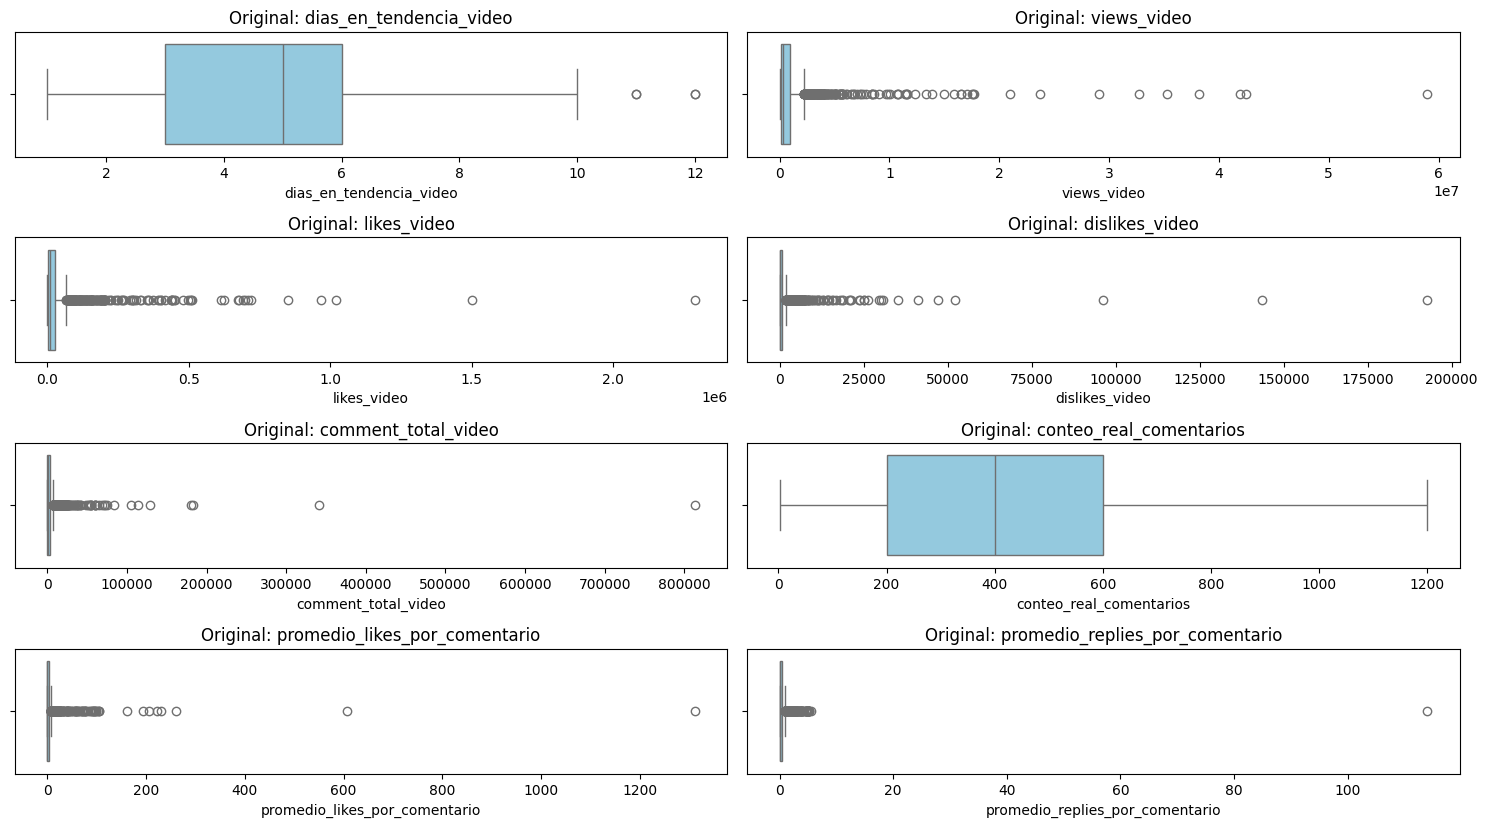

Conteo de Outliers por columna:
dislikes_video                     230
promedio_likes_por_comentario      210
comment_total_video                209
likes_video                        207
promedio_replies_por_comentario    200
views_video                        187
dias_en_tendencia_video              4
conteo_real_comentarios              0
dtype: int64


In [52]:
numeric_cols = ls_cont 
# Convertimos a float para que acepten los límites decimales del IQR
for col in numeric_cols:
    df[col] = df[col].astype('float64')

# Configuración de los cálculos IQR
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df = df.reset_index(drop=True)

# Visualización ANTES de la limpieza
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols) // 2 + 1, 2, i + 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Original: {col}')

plt.tight_layout()
plt.show()

# Mostrar el conteo de outliers 
outliers_mask = (df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))
print("Conteo de Outliers por columna:")
print(outliers_mask.sum().sort_values(ascending=False))

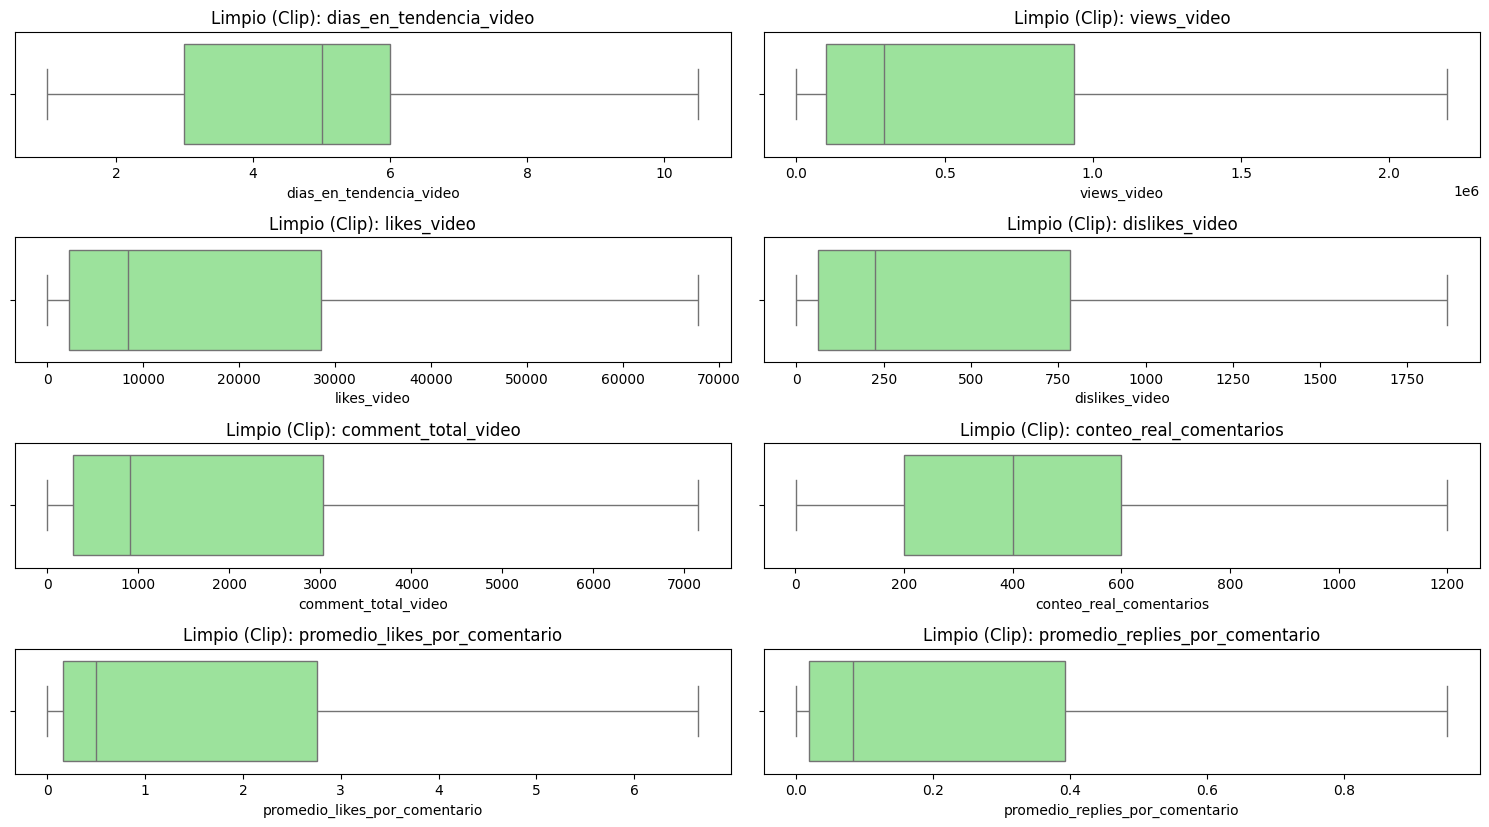

In [53]:
# Hacemos una copia para no alterar el original directamente
df_sin_outliers = df.copy()

#Aplicamos el tratamiento (Clip)
for col in numeric_cols:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    df_sin_outliers[col] = df_sin_outliers[col].clip(lower, upper)

#Visualización DESPUÉS de la limpieza
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols) // 2 + 1, 2, i + 1)
    sns.boxplot(x=df_sin_outliers[col], color='lightgreen')
    plt.title(f'Limpio (Clip): {col}')

plt.tight_layout()
plt.show()

### DETECCIÓN Y REMOCIÓN DE VARIABLE POCO POBLADAS

In [54]:
missing_ratio = df_sin_outliers.isnull().mean()
missing_ratio.sort_values(ascending=False)

promedio_replies_por_comentario    0.025346
promedio_likes_por_comentario      0.025346
conteo_real_comentarios            0.025346
category_video                     0.002304
video_id                           0.000000
dias_en_tendencia_video            0.000000
comment_total_video                0.000000
dislikes_video                     0.000000
likes_video                        0.000000
views_video                        0.000000
tags_video                         0.000000
channel_title                      0.000000
title_video                        0.000000
thumbnail_link                     0.000000
dtype: float64

In [55]:
low_populated_vars = missing_ratio[missing_ratio > 0.30].index.tolist()
low_populated_vars

[]

In [56]:
df.drop(columns=low_populated_vars, inplace=True)

#### DETECCIÓN Y REMOCIÓN DE VARIABLES UNITARIAS (UNARIAS)

In [57]:
list_columns = [
    col for col in df_sin_outliers.columns
    if df_sin_outliers[col].apply(lambda x: isinstance(x, list)).any()
]
unary_vars = [
    col for col in df_sin_outliers.columns
    if col not in list_columns and df_sin_outliers[col].nunique(dropna=True) == 1
]
unary_vars

[]

In [58]:
df_sin_outliers.drop(columns=unary_vars, inplace=True)
df_sin_outliers.head()

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,category_video,title_video,channel_title,tags_video,thumbnail_link,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario
0,--JinobXWPk,3.0,1874297.0,46933.0,653.0,7154.75,Pets & Animals,DANGEROUS Jungle Spider!,Brave Wilderness,adventure|adventurous|animals|breaking|breakin...,https://i.ytimg.com/vi/--JinobXWPk/default.jpg,300.0,0.200000,0.013333
1,--y69Ui8xwM,6.0,47188.0,410.0,19.0,109.00,Sports,FIFA Puskás Award 2017 - ALL NOMINEES,LilWiz,puskas award all nominees|FIFA Puskás Award 20...,https://i.ytimg.com/vi/--y69Ui8xwM/default.jpg,291.0,3.872852,0.951783
2,-1fzGnFwz9M,2.0,197531.0,7176.0,117.0,291.00,Pets & Animals,9 Things You Need To Know About Kittens - Simo...,Simon's Cat,cartoon|simons cat|simon's cat|simonscat|simon...,https://i.ytimg.com/vi/-1fzGnFwz9M/default.jpg,200.0,6.656824,0.205000
3,-2hRYEFiPSA,7.0,159476.0,4995.0,31.0,368.00,Music,Mike Shinoda of Linkin Park - KROQ Interview: ...,LPAssociation,linkin park|chester bennington|mike shinoda|on...,https://i.ytimg.com/vi/-2hRYEFiPSA/default.jpg,700.0,1.457143,0.092857
4,-6Zc8Co2H3w,8.0,2146662.0,52598.0,1381.0,7154.75,Film & Animation,Honest Trailers - Star Trek: The Next Generation,Screen Junkies,screen junkies|screenjunkies|sj news|honest tr...,https://i.ytimg.com/vi/-6Zc8Co2H3w/default.jpg,799.0,0.110000,0.003750
